# Customer Churn Analysis

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Customer churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

#replace blanks with 0 as tenure is 0 and no total changes are recorded

In [21]:
df["TotalCharges"] = df["TotalCharges"].replace("","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [25]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [30]:
df["customerID"].duplicated().sum()

np.int64(0)

In [33]:
def conv(value):
    if value == 1 :
        return "yes"
    else:
        return "no"

df['SeniorCitizen'] = df ["SeniorCitizen"].apply(conv) 
         

#Converted 0 and 1 values of senior citizen to yes/no to make it easier to understand

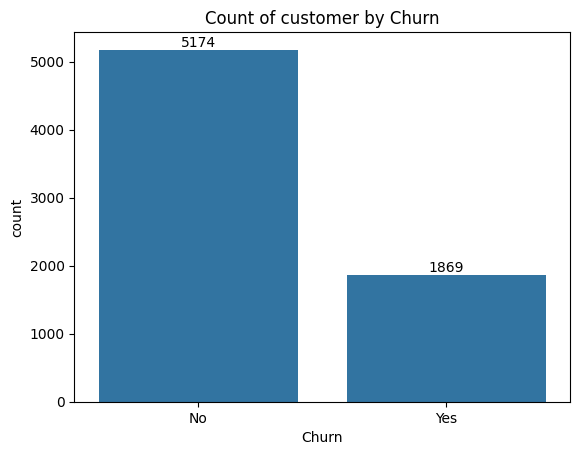

In [13]:
ax = sns.countplot(x = 'Churn' , data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of customer by Churn")
plt.show()

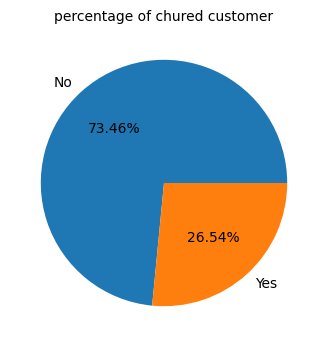

In [15]:
plt.figure(figsize =(5,4))
gb = df.groupby("Churn").agg({"Churn":"count"})
plt.pie(gb["Churn"], labels = gb.index, autopct = "%1.2f%%")
plt.title("Percentage of Chured Customer",fontsize =10)
plt.show()

#from the given pie chart we can canclude that 26.54% of our customers have churned out.
#not let's explore the reason behind it

<function matplotlib.pyplot.show(close=None, block=None)>

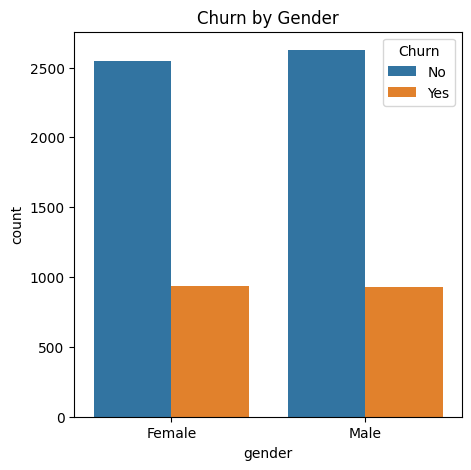

In [24]:
plt.figure(figsize = (5,5))
sns.countplot(x ="gender", data = df,hue ="Churn")
plt.title("Churn by Gender")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

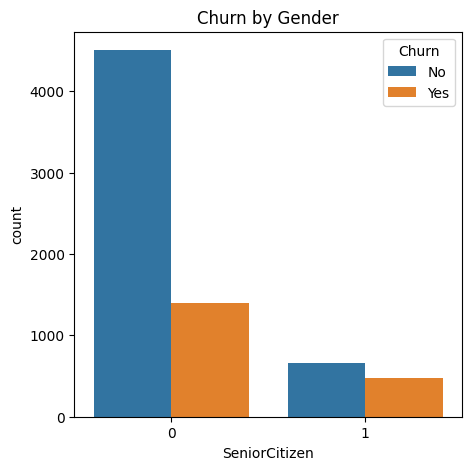

In [25]:
plt.figure(figsize = (3,3))
sns.countplot(x ="SeniorCitizen", data = df,hue ="Churn")
plt.title("Churn by Gender")
plt.show

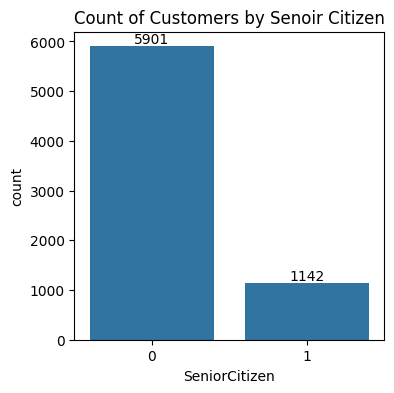

In [35]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x ="SeniorCitizen", data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Senoir Citizen")
plt.show()

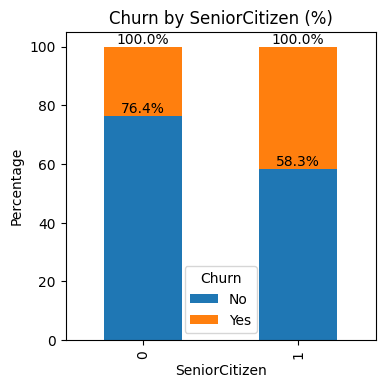

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# create percentage table
ct = pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100

# plot stacked bar chart
ax = ct.plot(kind="bar", stacked=True, figsize=(4,4))

# add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Churn by SeniorCitizen (%)")
plt.xlabel("SeniorCitizen")
plt.ylabel("Percentage")
plt.show()

#comparative a greater percentage of people in senior citizen category have churned

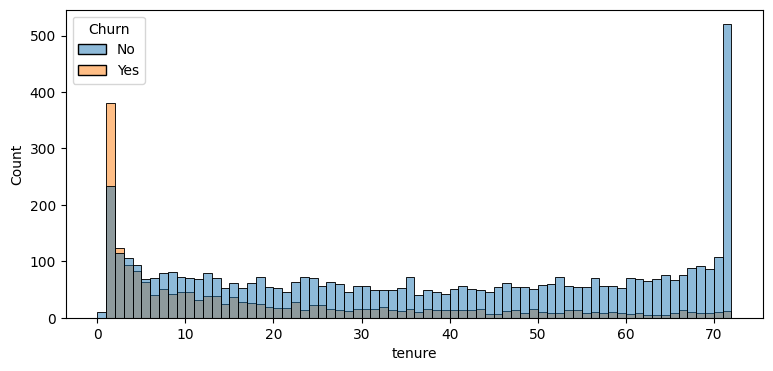

In [40]:
plt.figure(figsize = (9,4))
sns.histplot(x="tenure",data = df ,bins =72, hue = "Churn")
plt.show()

#peopel who have used our services our for a long thim have stayed and people who have used our services
#1 or 2 months have churned

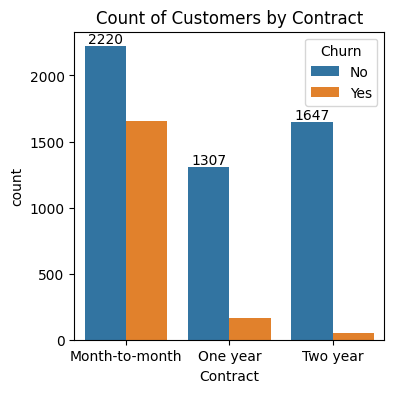

In [43]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x ="Contract", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.show()

In [45]:
#people who have month to month contract are likely to churn then from those who have 1 or 2 years or contract.

In [46]:
df.columns.values

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

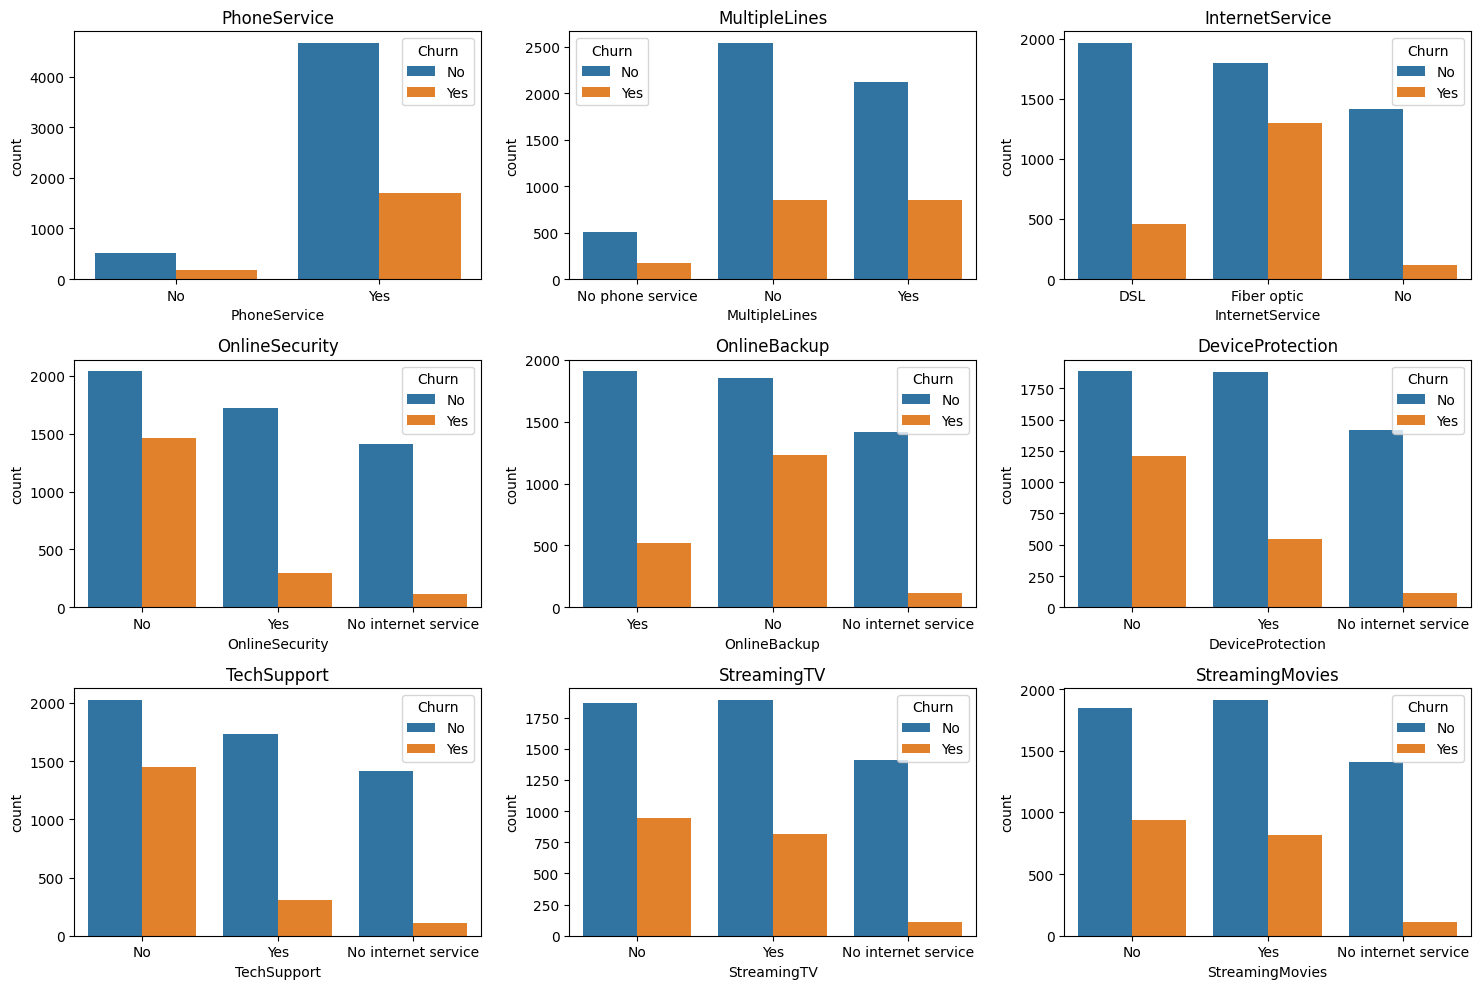

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['PhoneService','MultipleLines','InternetService',
        'OnlineSecurity','OnlineBackup','DeviceProtection',
        'TechSupport','StreamingTV','StreamingMovies']

fig, axes = plt.subplots(3,3, figsize=(15,10))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(x=col, data=df, ax=axes[i], hue = df["Churn"])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

#Customers with Fiber optic internet show the highest churn compared to DSL or no internet service.
#Customers who do not have OnlineSecurity, TechSupport, or DeviceProtection tend to churn more frequently.
#Users with PhoneService and MultipleLines still show some churn, but the majority remain with the service.
#Customers with additional services like StreamingTV and StreamingMovies generally have lower churn compared to those without these services.

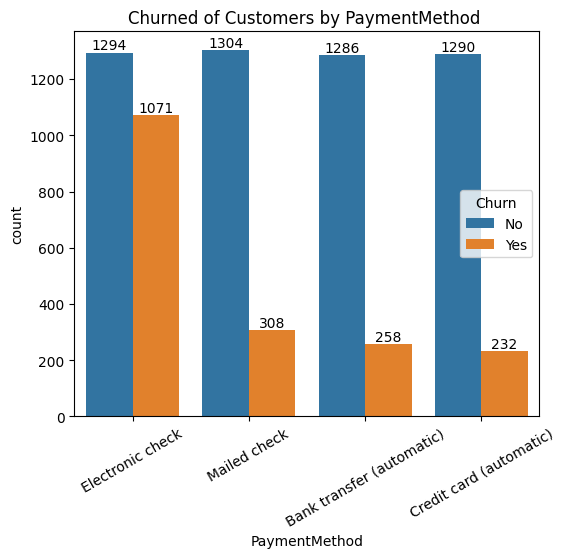

In [54]:
plt.figure(figsize = (6,5))
ax = sns.countplot(x ="PaymentMethod", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned of Customers by PaymentMethod ")
plt.xticks(rotation = 30)
plt.show()

#customer is likely to churn when he is using electronic check as a payment method.